<a href="https://colab.research.google.com/github/harmanbajwa2954/MRI_Brain_Tumor_Detection/blob/main/MRI_Brain_Tumor_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Brain Tumor Detection using MRI images

**Importing Packages**

In [6]:
# cloning the repository to access the dataset :
!git clone https://github.com/harmanbajwa2954/MRI_Brain_Tumor_Detection.git

Cloning into 'MRI_Brain_Tumor_Detection'...
remote: Enumerating objects: 238, done.
remote: Counting objects: 100% (238/238), done.
remote: Compressing objects: 100% (235/235), done.
remote: Total 238 (delta 3), reused 234 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (238/238), 6.84 MiB | 14.24 MiB/s, done.
Resolving deltas: 100% (3/3), done.


In [1]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score
import cv2

## Reading the MRI image data

In [11]:
# Reading images with Tumor
tumor = []
yes_path = '/content/MRI_Brain_Tumor_Detection/brain_tumor_dataset/yes/*.jpg'

for f in glob.iglob(yes_path):
  img = cv2.imread(f)
  img = cv2.resize(img, (128, 128))         #resizing the images for better results :)
  b, g, r = cv2.split(img)
  img = cv2.merge([r, g, b])
  tumor.append(img)
print("Successfully loaded test image with shape:", len(tumor))

Successfully loaded test image with shape: 86


In [12]:
#printing the size of each image
for img in tumor:
  print(img.shape)

(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 

In [13]:
# Reading images without tumor
no_tumor  =[]
no_path = '/content/MRI_Brain_Tumor_Detection/brain_tumor_dataset/no/*.jpg'

for f in glob.iglob(no_path):
  img = cv2.imread(f)
  img = cv2.resize(img, (128, 128))         #resizing the images for better results :)
  b, g, r = cv2.split(img)
  img = cv2.merge([r, g, b])
  no_tumor.append(img)
print("Successfully loaded test image with shape:", len(no_tumor))

Successfully loaded test image with shape: 85


In [15]:
#printing the size of each healthy image
for img in no_tumor:
  print(img.shape)

(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 

**Converting Images list to Numpy Arrays**

In [19]:
healthy = np.array(no_tumor)
tumor = np.array(tumor)
print('The Shape of Healthy array :', healthy.shape)
print('The Shape of Tumor array :', tumor.shape)

The Shape of Healthy array : (85, 128, 128, 3)
The Shape of Tumor array : (86, 128, 128, 3)


In [20]:
# Combining both healthya and tumor arrays
All = np.concatenate((healthy, tumor))
All.shape

(171, 128, 128, 3)

## Visualizing Brain MRI images

In [26]:
# A Function to Randomly visualize N healthy and tumor MRI images
def plot_random(healthy, tumor, num=5):
  healthy_img = healthy[np.random.choice(healthy.shape[0], num, replace=False)]
  tumor_img = tumor[np.random.choice(tumor.shape[0], num, replace=False)]

#for healthy images
  plt.figure(figsize=(16,9))
  for i in range(num):
    plt.subplot(1, num, i+1)
    plt.title('Healthy')
    plt.imshow(healthy_img[i])

# For tumor images
  plt.figure(figsize=(16,9))
  for i in range(num):
    plt.subplot(2, num, i+1)
    plt.title('Tumor')
    plt.imshow(tumor_img[i])

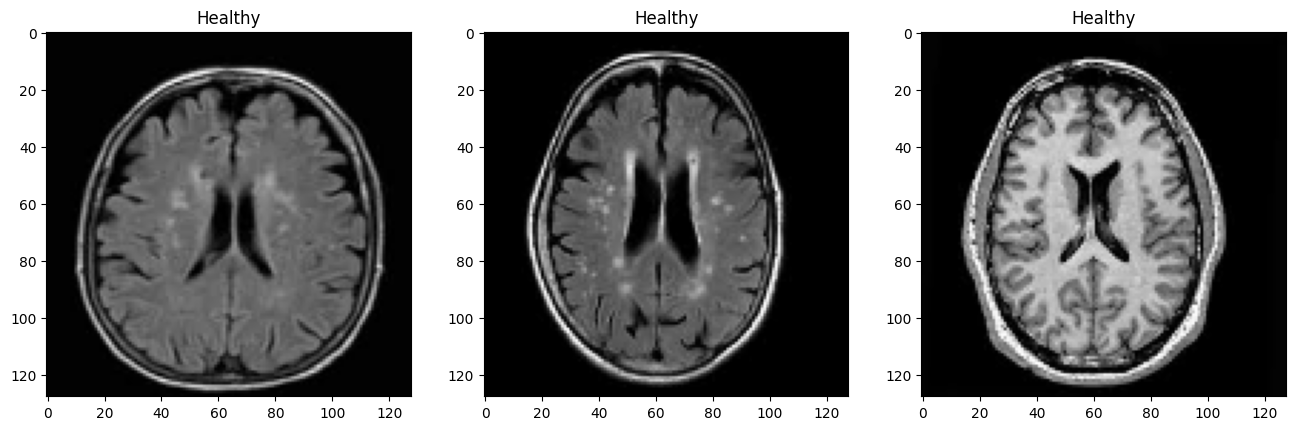

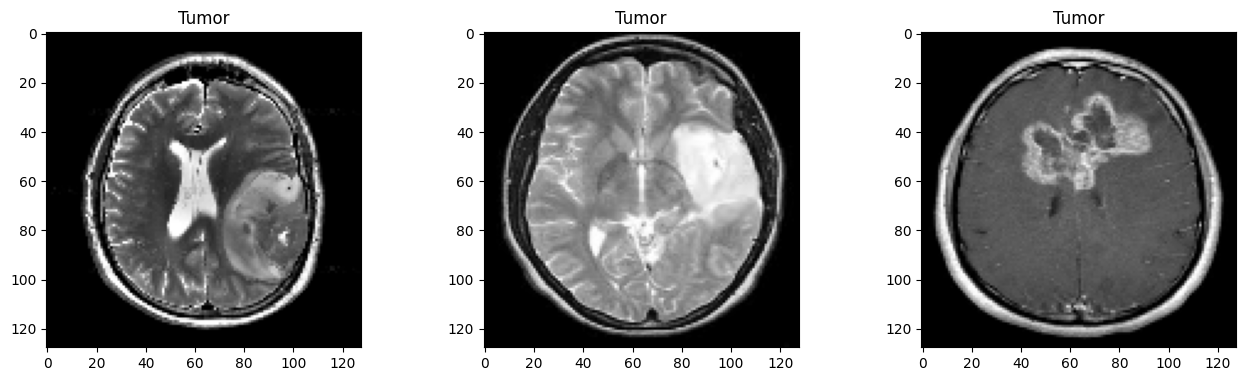

In [27]:
plot_random(healthy, tumor, 3)

## Creating Torch Dataset Class

**Pytorch's Abstract Dataset Class**

In [28]:
class Dataset(object):

  # An abstract class representing a Dataset.
  #all other datsets should subclass it. All subclasses shoud overrride
  # ``__len__``, that provides the size of the dataset, and ``__getitem__``,
  #  supporting integer indexing in range form 0 to len(self) exclusive.

  def __getitem__(self, index):
    raise NotImplementedError

  def __len__(self):
    raise NotImplementedError

  def __add__(self, other):
    return ConcatDataset([self, other])
